In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("final_results.csv")

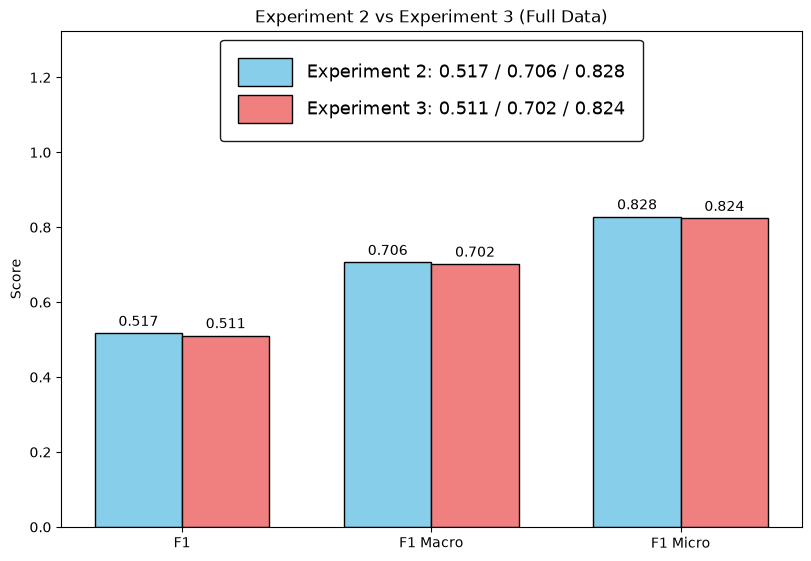

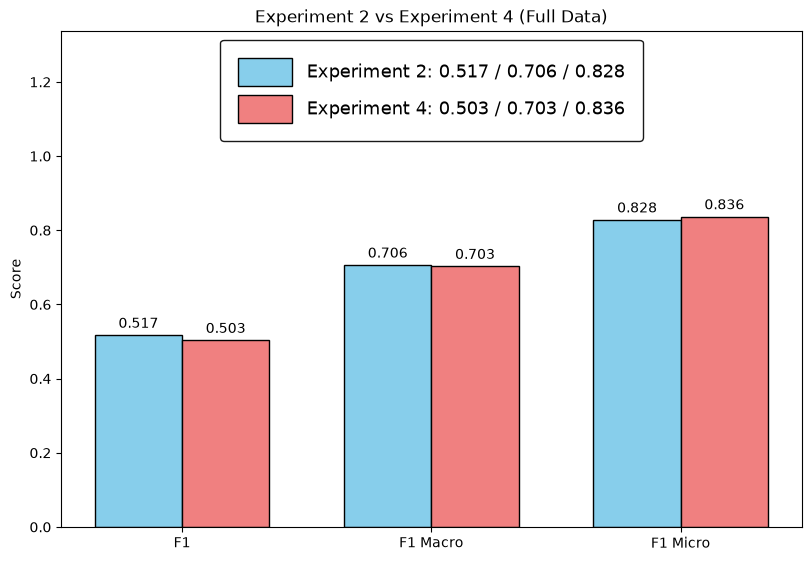

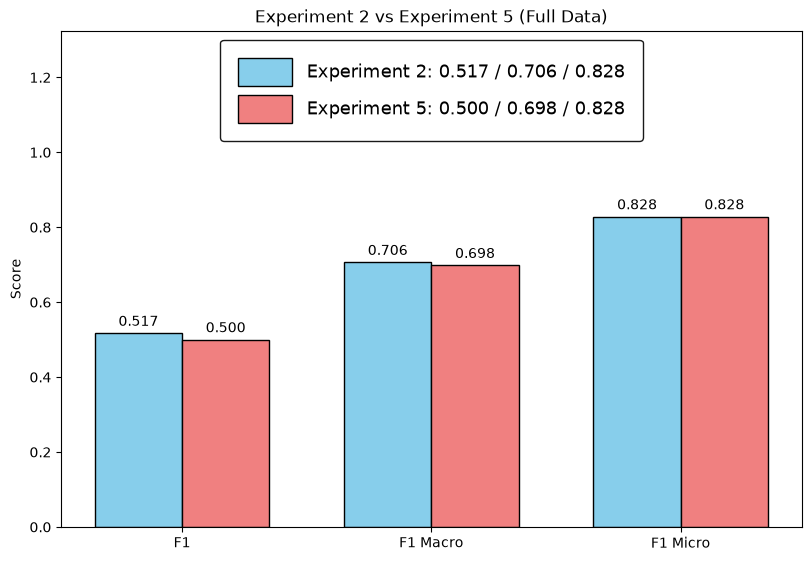

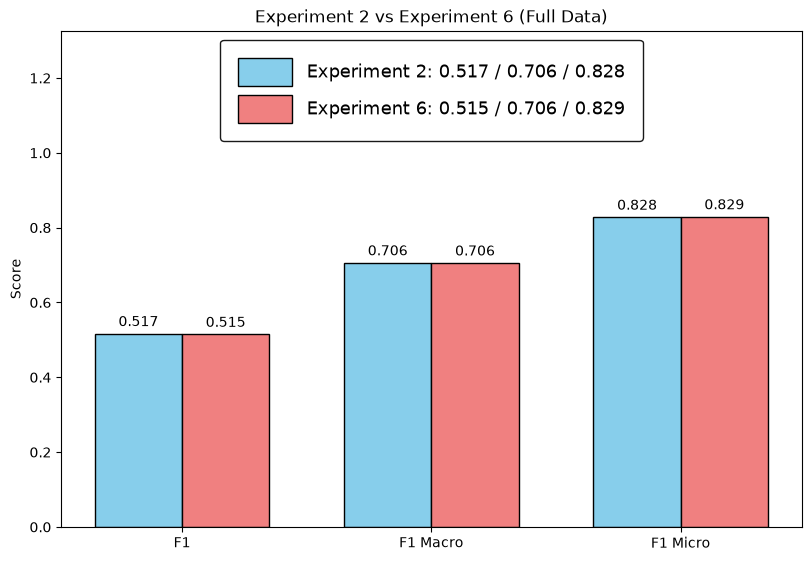

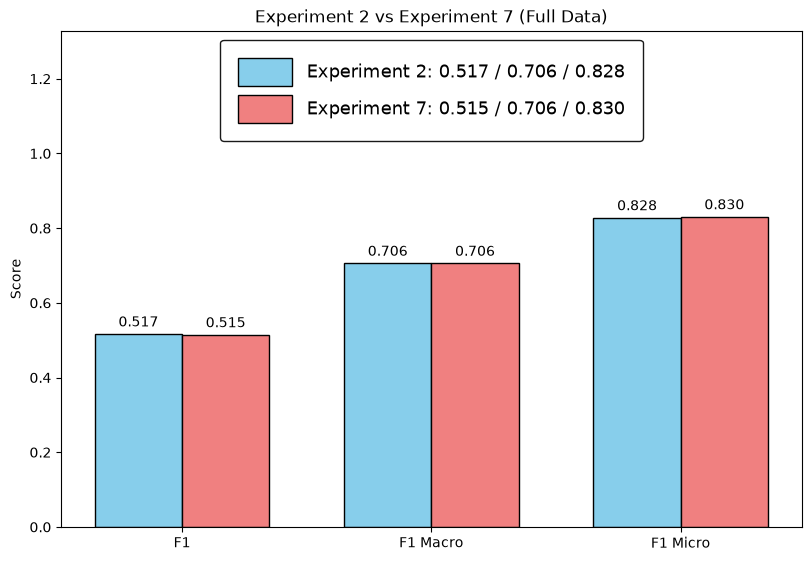

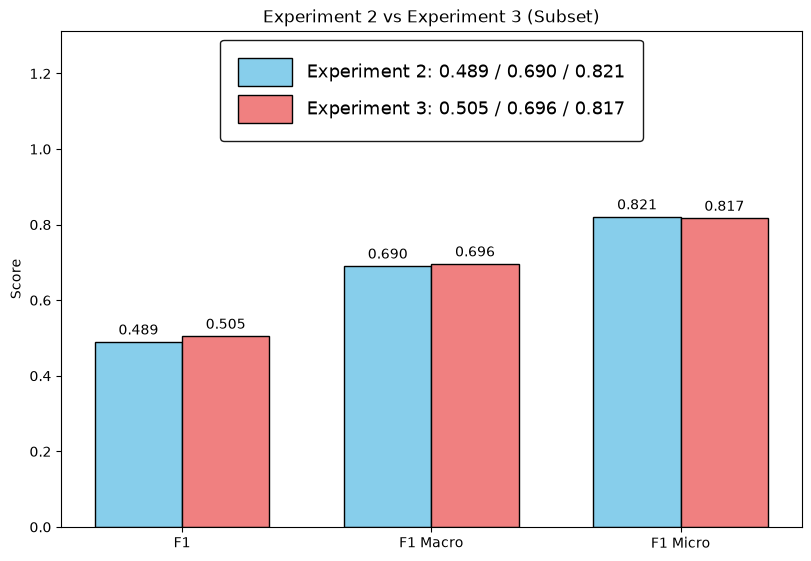

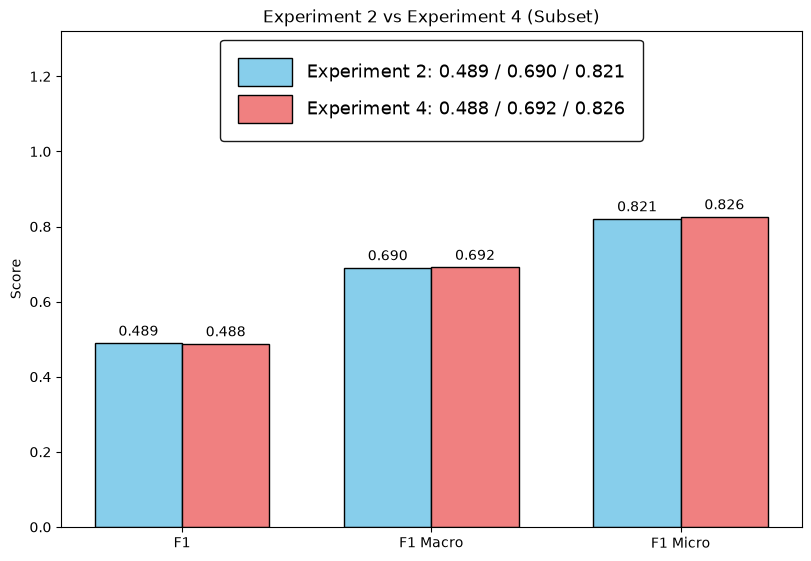

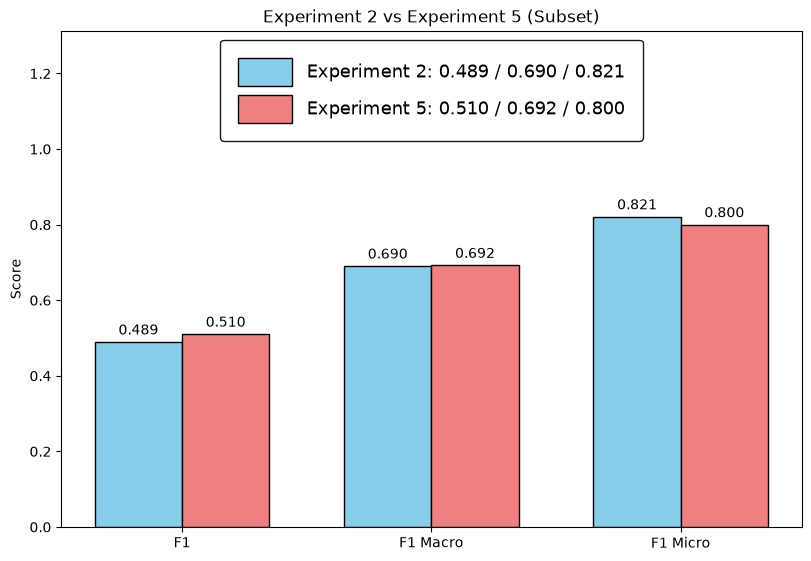

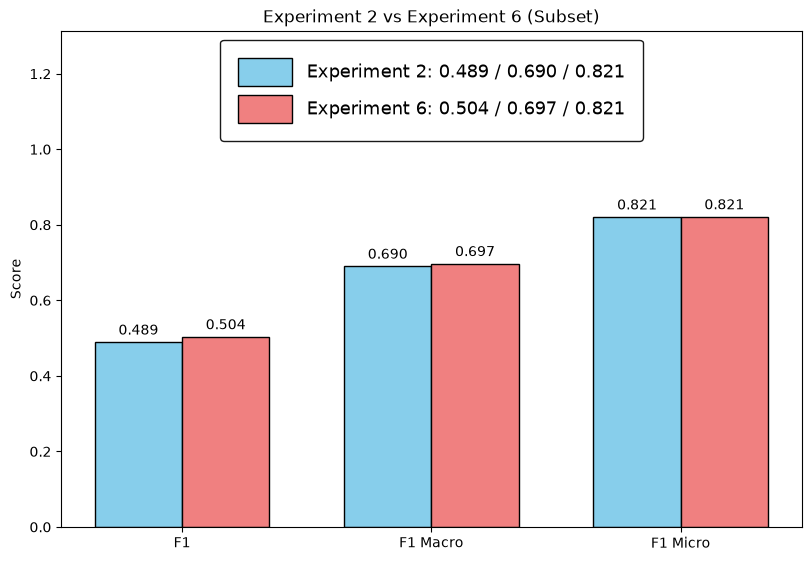

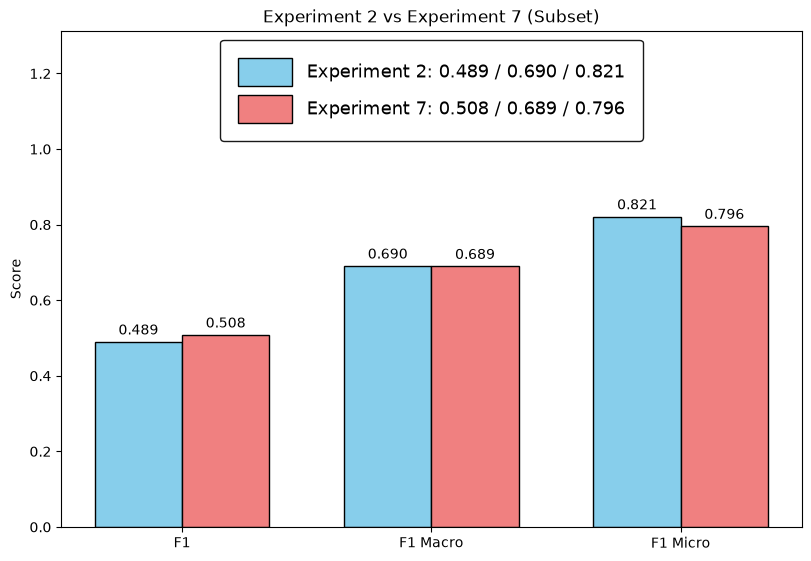

In [20]:
def plot_exp_comparison(other_experiment, split="f", save_path=None, loc="upper center"):
    metrics = ["f1", "f1_macro", "f1_micro"]
    metric_labels = ["F1", "F1 Macro", "F1 Micro"]

    row2 = df[(df["experiment"] == 2) & (df["split"] == split)].iloc[0]
    rowN = df[(df["experiment"] == other_experiment) & (df["split"] == split)].iloc[0]

    vals2 = row2[metrics].astype(float).values
    valsN = rowN[metrics].astype(float).values

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(constrained_layout=True, figsize=(8, 5.5))
    bars2 = ax.bar(x - width/2, vals2, width, color="skyblue", edgecolor="black")
    barsN = ax.bar(x + width/2, valsN, width, color="lightcoral", edgecolor="black")

    ax.bar_label(bars2, padding=3, fmt="%.3f")
    ax.bar_label(barsN, padding=3, fmt="%.3f")

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel("Score")
    ax.set_title(f"Experiment 2 vs Experiment {other_experiment} ({"Full Data" if split=="f" else "Subset"})")

    # headroom above the tallest bar so the in-axes legend doesn't overlap bars
    ax.set_ylim(0, max(vals2.max(), valsN.max()) * 1.6)

    legend_labels = [
        f"Experiment 2: {vals2[0]:.3f} / {vals2[1]:.3f} / {vals2[2]:.3f}",
        f"Experiment {other_experiment}: {valsN[0]:.3f} / {valsN[1]:.3f} / {valsN[2]:.3f}",
    ]
    ax.legend(
        [bars2, barsN], legend_labels,
        loc=loc, ncol=1, frameon=True, framealpha=0.9, edgecolor="black",
        fontsize=13,          # text size
        handlelength=3,       # width of the color swatch
        handleheight=2,       # height of the color swatch
        borderpad=1,        # padding inside the legend box
        labelspacing=0.5,     # vertical space between entries
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig, ax

for n in [3, 4, 5, 6, 7]:
    plot_exp_comparison(n, save_path=f"exp2_vs_{n}_f.png")

for n in [3, 4, 5, 6, 7]:
    plot_exp_comparison(n, split="s", save_path=f"exp2_vs_{n}_s.png")